In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.neighbors import NearestNeighbors
from sklearn.linear_model import LogisticRegression

In [2]:
data = pd.read_csv("../HW3/data/output/final_star.csv")

/tmp/ipykernel_3877396/3584565233.py:1: DtypeWarning: Columns (100,101,102,103,104,105,106,107,108,111) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("../HW3/data/output/final_star.csv")


In [3]:
print(list(data.columns))

['contractid', 'planid', 'fips', 'year', 'n_nonmiss', 'avg_enrollment', 'sd_enrollment', 'min_enrollment', 'max_enrollment', 'first_enrollment', 'last_enrollment', 'state', 'county', 'org_type', 'plan_type', 'partd', 'snp', 'eghp', 'org_name', 'org_marketing_name', 'plan_name', 'parent_org', 'contract_date', 'state_long', 'county_long', 'year_pen', 'n_elig', 'n_enrol', 'avg_eligibles', 'sd_eligibles', 'min_eligibles', 'max_eligibles', 'first_eligibles', 'last_eligibles', 'avg_enrolled', 'sd_enrolled', 'min_enrolled', 'max_enrolled', 'first_enrolled', 'last_enrolled', 'ssa', 'state_name', 'state_land', 'premium', 'premium_partc', 'premium_partd_basic', 'premium_partd_supp', 'premium_partd_total', 'partd_deductible', 'year_land', 'riskscore_partc', 'payment_partc', 'rebate_partc', 'year_reb', 'payment_partd', 'directsubsidy_partd', 'reinsurance_partd', 'costsharing_partd', 'riskscore_partd', 'avg_ffscost', 'parta_enroll', 'partb_enroll', 'metric_01', 'metric_02', 'metric_03', 'metric_04'

In [4]:
# Question 1: 

d1 = data.copy()

# choose and clean variables
d1["star_rating"] = pd.to_numeric(d1["partcd_score"], errors="coerce")  # overall star rating proxy
d1["enrollment"] = pd.to_numeric(d1["avg_enrollment"], errors="coerce")
d1["market_share"] = np.where(
    pd.to_numeric(d1["avg_enrolled"], errors="coerce") > 0,
    d1["enrollment"] / pd.to_numeric(d1["avg_enrolled"], errors="coerce"),
    np.nan
)

# create table
summary = (
    d1.loc[d1["year"].between(2010, 2015)]
      .groupby("year")
      .agg(
          mean_star_rating=("star_rating", "mean"),
          mean_enrollments=("enrollment", "mean"),
          mean_market_share=("market_share", "mean"),
          n_plans=("planid", "count"),
      )
      .reset_index()
      .sort_values("year")
)

summary

,year,mean_star_rating,mean_enrollments,mean_market_share,n_plans
0,2010,2.969662,256.353663,0.064564,108222
1,2011,3.165988,343.358734,0.085547,68003
2,2012,3.352218,377.336484,0.085568,67254
3,2013,3.559948,395.516174,0.081451,68117
4,2014,3.824169,436.637121,0.079989,62344
5,2015,3.977247,469.679258,0.078689,65507


In [5]:
# Question 2

no_star_summary = (
    data.loc[data["year"].between(2010, 2015)]
        .assign(
            star_rating=lambda d: pd.to_numeric(d["partcd_score"], errors="coerce"),
            enrollment=lambda d: pd.to_numeric(d["avg_enrollment"], errors="coerce"),
            market_share=lambda d: np.where(
                pd.to_numeric(d["avg_enrolled"], errors="coerce") > 0,
                pd.to_numeric(d["avg_enrollment"], errors="coerce") / pd.to_numeric(d["avg_enrolled"], errors="coerce"),
                np.nan
            ),
        )
        .loc[lambda d: d["star_rating"].isna()]  # plans without a star rating
        .groupby("year")
        .agg(
            mean_enrollments=("enrollment", "mean"),
            mean_market_share=("market_share", "mean"),
            n_plans_no_star=("planid", "count"),
        )
        .reset_index()
        .sort_values("year")
)

no_star_summary

,year,mean_enrollments,mean_market_share,n_plans_no_star
0,2010,107.336869,0.066018,48643
1,2011,172.482650,0.087729,17195
2,2012,172.734040,0.056712,9077
3,2013,213.504441,0.060017,3661
4,2014,257.596264,0.055713,3708
5,2015,328.243183,0.051313,5338


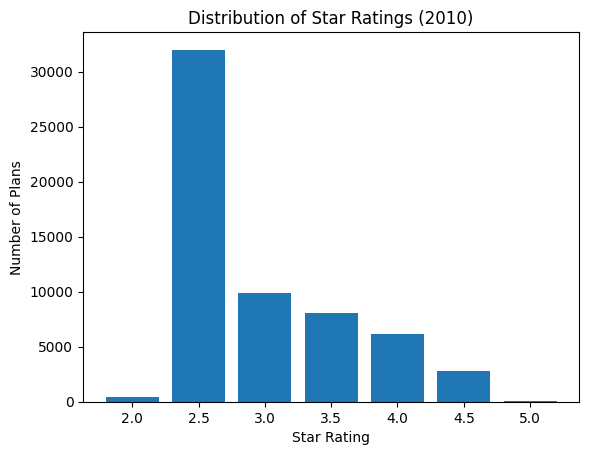

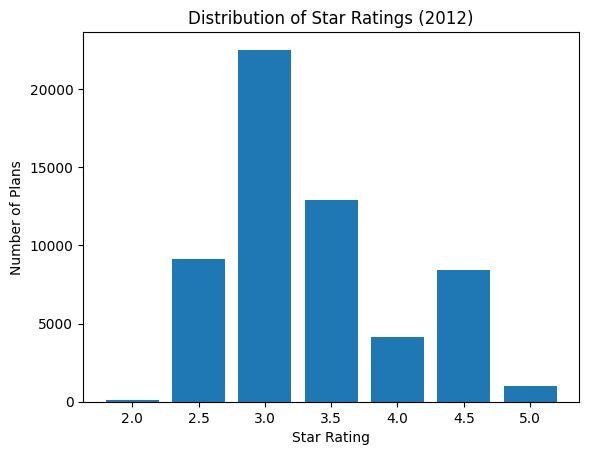

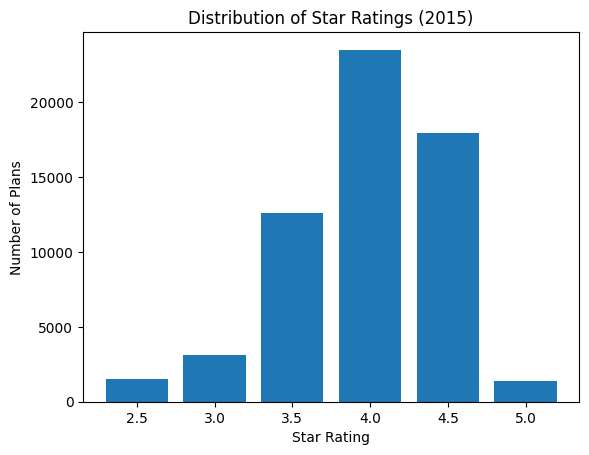

In [6]:
# question 3

# Clean star ratings (numeric)
df = data.copy()
df["star_rating"] = pd.to_numeric(df["partcd_score"], errors="coerce")

# Only rated plans and target years
years = [2010, 2012, 2015]
df = df[df["year"].isin(years) & df["star_rating"].notna()]


for y in years:
    sub = df[df["year"] == y]

    counts = (
        sub["star_rating"]
        .value_counts()
        .sort_index()
    )

    plt.figure()
    plt.bar(counts.index.astype(str), counts.values)
    plt.title(f"Distribution of Star Ratings ({y})")
    plt.xlabel("Star Rating")
    plt.ylabel("Number of Plans")
    plt.show()

In [7]:
#Question 4

df = data.copy()

# Dependent variable: market share (plan enrollment / total enrolled in county)
df["market_share"] = np.where(
    pd.to_numeric(df["avg_enrolled"], errors="coerce") > 0,
    pd.to_numeric(df["avg_enrollment"], errors="coerce") / pd.to_numeric(df["avg_enrolled"], errors="coerce"),
    np.nan
)

# Star rating 
df["star"] = pd.to_numeric(df["partcd_score"], errors="coerce")

# Star bucket indicators (excluded category: star <= 2.5)
df["star_3"]  = ((df["star"] > 2.5) & (df["star"] < 3.5)).astype(int)   # approx 3.0
df["star_35"] = ((df["star"] >= 3.5) & (df["star"] < 4.0)).astype(int)  # 3.5
df["star_4"]  = ((df["star"] >= 4.0) & (df["star"] < 4.5)).astype(int)  # 4.0
df["star_45p"] = (df["star"] >= 4.5).astype(int)                        # 4.5+

years = range(2010, 2016)
rows = ["Intercept", "Star = 3.0", "Star = 3.5", "Star = 4.0", "Star >= 4.5", "N"]

coef_table = pd.DataFrame(index=rows, columns=[str(y) for y in years], dtype=object)

for y in years:
    sub = df[(df["year"] == y) & df["market_share"].notna()].copy()

    X = sub[["star_3", "star_35", "star_4", "star_45p"]]
    X = sm.add_constant(X)
    yvec = sub["market_share"]

    model = sm.OLS(yvec, X, missing="drop").fit()

    # Fill table with coef 
    coef_table.loc["Intercept", str(y)] = f"{model.params.get('const', np.nan):.4f} ({model.bse.get('const', np.nan):.4f})"
    coef_table.loc["Star = 3.0", str(y)] = f"{model.params.get('star_3', np.nan):.4f} ({model.bse.get('star_3', np.nan):.4f})"
    coef_table.loc["Star = 3.5", str(y)] = f"{model.params.get('star_35', np.nan):.4f} ({model.bse.get('star_35', np.nan):.4f})"
    coef_table.loc["Star = 4.0", str(y)] = f"{model.params.get('star_4', np.nan):.4f} ({model.bse.get('star_4', np.nan):.4f})"
    coef_table.loc["Star >= 4.5", str(y)] = f"{model.params.get('star_45p', np.nan):.4f} ({model.bse.get('star_45p', np.nan):.4f})"
    coef_table.loc["N", str(y)] = int(model.nobs)

coef_table

,2010,2011,2012,2013,2014,2015
Intercept,0.0644 (0.0007),0.0804 (0.0012),0.0661 (0.0017),0.0532 (0.0020),0.0614 (0.0026),0.0540 (0.0021)
Star = 3.0,0.0102 (0.0018),0.0236 (0.0019),0.0417 (0.0021),0.0602 (0.0027),0.0229 (0.0034),0.0374 (0.0035)
Star = 3.5,-0.0014 (0.0019),0.0084 (0.0024),0.0251 (0.0025),0.0339 (0.0023),0.0328 (0.0029),0.0503 (0.0027)
Star = 4.0,-0.0055 (0.0021),-0.0094 (0.0036),-0.0082 (0.0035),0.0189 (0.0032),0.0104 (0.0032),0.0166 (0.0024)
Star >= 4.5,-0.0093 (0.0028),-0.0215 (0.0029),-0.0001 (0.0027),0.0148 (0.0027),0.0072 (0.0031),0.0278 (0.0025)
N,30545,24194,24297,25219,24636,24852


In [10]:
# Question 5

d5 = data.loc[data["year"] == 2010].copy()

d5["star"] = pd.to_numeric(d5["partcd_score"], errors="coerce")

#running variable
running_col = "partcd_score"  

if running_col not in d5.columns:
    raise KeyError(
        f"'{running_col}' not found. You need a continuous underlying score column to construct the RD running variable."
    )

d5["running"] = pd.to_numeric(d5[running_col], errors="coerce")

bins = [2.75, 3.25, 3.75, 4.25, 4.75, 5.25]
labels = ["3.0", "3.5", "4.0", "4.5", "5.0"]

d5["rounded_up_to"] = pd.cut(d5["running"], bins=bins, right=False, labels=labels)

rounded_counts = (
    d5.loc[d5["rounded_up_to"].notna()]
      .groupby("rounded_up_to")
      .size()
      .reindex(labels, fill_value=0)
      .reset_index(name="n_plans")
      .rename(columns={"rounded_up_to": "rounded_up_star"})
)

rounded_counts

/tmp/ipykernel_3877396/3715206539.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("rounded_up_to")


,rounded_up_star,n_plans
0,3.0,9918
1,3.5,8091
2,4.0,6167
3,4.5,2831
4,5.0,102


In [11]:
#Quesiton 6
d6 = data.loc[data["year"] == 2010].copy()

d6["star"] = pd.to_numeric(d6["partcd_score"], errors="coerce")

# Running variable 
running_col = "partcd_score"
d6"running"] = pd.to_numeric(d6[running_col], errors="coerce")


outcome_col = "avg_enrollment"
d6[outcome_col] = pd.to_numeric(d6[outcome_col], errors="coerce")


# RD 
def rd_local_linear(df, outcome, running="running", cutoff=2.75, h=0.125):
    d = df[[outcome, running]].dropna().copy()
    d = d.loc[(d[running] >= cutoff - h) & (d[running] <= cutoff + h)].copy()
    d["treat"] = (d[running] >= cutoff).astype(int)
    d["x"] = d[running] - cutoff
    d["treat_x"] = d["treat"] * d["x"]

    X = sm.add_constant(d[["treat", "x", "treat_x"]])
    y = d[outcome]

    m = sm.OLS(y, X).fit(cov_type="HC1")

    out = {
        "cutoff": cutoff,
        "bandwidth": h,
        "n": int(m.nobs),
        "tau_hat": float(m.params["treat"]),
        "se_HC1": float(m.bse["treat"]),
        "p_value": float(m.pvalues["treat"]),
    }
    return out


#  Run RDs
h = 0.125

res_30 = rd_local_linear(d6, outcome=outcome_col, cutoff=2.75, h=h)  # 2.5 -> 3.0
res_35 = rd_local_linear(d6, outcome=outcome_col, cutoff=3.25, h=h)  # 3.0 -> 3.5

results = pd.DataFrame([
    {"comparison": "3.0 vs 2.5 (cutoff 2.75)", **res_30},
    {"comparison": "3.5 vs 3.0 (cutoff 3.25)", **res_35},
])

# formatting
results["ci95_low"]  = results["tau_hat"] - 1.96 * results["se_HC1"]
results["ci95_high"] = results["tau_hat"] + 1.96 * results["se_HC1"]

results = results[[
    "comparison", "cutoff", "bandwidth", "n",
    "tau_hat", "se_HC1", "ci95_low", "ci95_high", "p_value"
]]

results

SyntaxError: unmatched ']' (3271849084.py, line 8)